<a href="https://colab.research.google.com/github/senohmbi-debug/ITCS-3162/blob/main/lab_04_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 — Exercise: Exploring World Stock Market Indices

**ITCS 3162 — Introduction to Data Mining**

**Name:** Sean Enohmbi

**Date:** June 1, 2026

You'll explore daily prices for six major world stock indices over five years (2020–2024). Unlike penguins, this is **time-series data with a categorical dimension (ticker)** — you'll need to think about both the temporal structure and cross-sectional comparisons.

You have **two options** for loading the data — use whichever you prefer:

- **Option A (default):** Load the included `world_indices.csv` — pre-built, works offline, gives consistent results.
- **Option B (live fetch):** Download fresh data directly from Yahoo Finance using the `yfinance` library. This is how real analysts pull market data, but it requires internet and Yahoo's API can be flaky.

Both options produce a DataFrame with the same columns, so the rest of the notebook works identically.

| Column | Notes |
|---|---|
| `Date` | Trading day |
| `Ticker` | Yahoo Finance symbol (e.g. `^GSPC` for S&P 500) |
| `Name` | Full index name |
| `Country` | Country |
| `Open`, `High`, `Low`, `Close` | Daily prices |
| `Volume` | Trading volume (has some missing values) |

When you're done, **Restart & Run All**, download as `.ipynb`, and submit via Canvas.


## Setup — imports


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

## Load the data — pick ONE option

Set `USE_LIVE_FETCH = False` for the default CSV (recommended), or `True` to try the live yfinance API. Then run the cell below it.


In [2]:
USE_LIVE_FETCH = True   # set to True to pull fresh data from Yahoo Finance

### Option A — Load the included CSV (runs when `USE_LIVE_FETCH = False`)
### Option B — Live fetch from Yahoo Finance (runs when `USE_LIVE_FETCH = True`)

The cell below handles both. Option B uses the `yfinance` package — if you've never installed it, the cell will install it for you (`!pip install yfinance`). If the fetch fails (network down, API rate-limit, etc.), the code automatically falls back to the CSV so the rest of the notebook still works.


In [3]:
if USE_LIVE_FETCH:
    tickers_meta = {
        "^GSPC":  ("S&P 500",                      "USA"),
        "^DJI":   ("Dow Jones Industrial Average", "USA"),
        "^IXIC":  ("NASDAQ Composite",             "USA"),
        "^FTSE":  ("FTSE 100",                     "United Kingdom"),
        "^N225":  ("Nikkei 225",                   "Japan"),
        "^GDAXI": ("DAX",                          "Germany"),
    }

    try:
        # Install yfinance if it isn't already available. The --break-system-packages
        # flag is needed on some Linux setups (including Colab in some configurations).
        try:
            import yfinance as yf
        except ImportError:
            import sys, subprocess
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
            except subprocess.CalledProcessError:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                                       "--break-system-packages", "yfinance"])
            import yfinance as yf

        # auto_adjust=True gives adjusted prices; group_by='ticker' returns one
        # block per symbol so it's easy to flatten into long format.
        raw = yf.download(
            list(tickers_meta.keys()),
            start="2020-01-02",
            end="2025-01-01",
            auto_adjust=True,
            group_by="ticker",
            progress=False,
        )

        # Flatten the wide MultiIndex DataFrame into long format
        frames = []
        for tk, (name, country) in tickers_meta.items():
            sub = raw[tk].copy().reset_index()
            sub["Ticker"]  = tk
            sub["Name"]    = name
            sub["Country"] = country
            frames.append(sub[["Date","Ticker","Name","Country","Open","High","Low","Close","Volume"]])
        df = pd.concat(frames, ignore_index=True).dropna(subset=["Close"])

        # yfinance returns an empty frame (not an error) when blocked or rate-limited.
        # Treat an empty result as a failure so we fall back to the CSV.
        if len(df) == 0:
            raise RuntimeError("yfinance returned no rows (likely network-blocked or rate-limited)")

        print(f"Live fetch succeeded — {df.shape[0]:,} rows from Yahoo Finance.")
    except Exception as e:
        print(f"Live fetch failed ({type(e).__name__}: {e}). Falling back to CSV.")
        df = pd.read_csv("world_indices.csv", parse_dates=["Date"])
else:
    df = pd.read_csv("world_indices.csv", parse_dates=["Date"])
    print(f"Loaded CSV — {df.shape[0]:,} rows.")

print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Live fetch succeeded — 7,532 rows from Yahoo Finance.
Date range: 2020-01-02 to 2024-12-31


Price,Date,Ticker,Name,Country,Open,High,Low,Close,Volume
0,2020-01-02,^GSPC,S&P 500,USA,3244.669922,3258.139893,3235.530029,3257.850098,3.459930e+09
1,2020-01-03,^GSPC,S&P 500,USA,3226.360107,3246.149902,3222.340088,3234.850098,3.484700e+09
2,2020-01-06,^GSPC,S&P 500,USA,3217.550049,3246.840088,3214.639893,3246.280029,3.702460e+09
3,2020-01-07,^GSPC,S&P 500,USA,3241.860107,3244.909912,3232.429932,3237.179932,3.435910e+09
4,2020-01-08,^GSPC,S&P 500,USA,3238.590088,3267.070068,3236.669922,3253.050049,3.726840e+09


## Exercise 1 — Initial profile (10 pts)

In the cell below:
1. Print `df.info()`
2. Print the count of rows for each `Ticker`
3. Print the count of missing values per column

Then answer the questions in the next markdown cell.


In [4]:
# TODO: info, rows per ticker, missing per column
print(df.info())
print(df['Ticker'].value_counts())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 7532 entries, 0 to 7810
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     7532 non-null   datetime64[ns]
 1   Ticker   7532 non-null   object        
 2   Name     7532 non-null   object        
 3   Country  7532 non-null   object        
 4   Open     7532 non-null   float64       
 5   High     7532 non-null   float64       
 6   Low      7532 non-null   float64       
 7   Close    7532 non-null   float64       
 8   Volume   7532 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 588.4+ KB
None
Ticker
^GDAXI    1275
^FTSE     1261
^DJI      1258
^GSPC     1258
^IXIC     1258
^N225     1222
Name: count, dtype: int64
Price
Date       0
Ticker     0
Name       0
Country    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64


**Answers:**
1. Do all six indices have the same number of rows? Why might they differ?
2. Which column has the most missing values? What's a plausible real-world reason?


**1. The six indices have different numbers of rows, which could have something to do with the dtypes.**

**2. They all appear to have a similar number of missing values, which could be because the data was chosen because they were complete.**

## Exercise 2 — Numeric summary by ticker (10 pts)

Produce a table where each row is one ticker, with columns:
- `mean_close`, `std_close`, `min_close`, `max_close`

Round to 2 decimals. Sort by `mean_close` descending.


In [9]:
# TODO: groupby summary by Ticker
table_df = (
    df.groupby('Ticker')
    .agg(mean_close = 'mean', std_close = 'std', min_close = 'min', max_close = 'max')
    .round(2)
    .sort_values(by = 'mean_close', ascending = False)
)

TypeError: Must provide 'func' or tuples of '(column, aggfunc).

## Exercise 3 — Time series plot (15 pts)

Make a single line plot showing `Close` over `Date`, one line per ticker.

Hint: `sns.lineplot(data=df, x="Date", y="Close", hue="Ticker")` will work, but the indices have very different absolute values (the Nikkei is in the tens of thousands of yen, while the FTSE is in the thousands of pounds), so the lines won't be comparable.

**Fix this** by normalizing each ticker so its first close = 100. This gives a fair comparison of returns. Steps:

1. Sort by Date within each ticker.
2. For each ticker, compute `Close_normalized = Close / first_close * 100`.
3. Plot `Close_normalized` over `Date`, colored by ticker.


In [6]:
# TODO: comp mute normalized close
df = df.sort_values(by=['Ticker', 'Date'])

# TODO: line plot
first_close = df.groupby('Ticker')['Close'].transform('first')
df['Close_normalized'] = df['Close'] / first_close * 100

## Exercise 4 — Daily returns distribution (15 pts)

Compute the **daily percent return** for each ticker: `return = (Close - prev_Close) / prev_Close`.

Hint: within each ticker, use `groupby("Ticker")["Close"].pct_change()`.

Then make a histogram (or KDE plot) showing the distribution of daily returns, with one panel per ticker (a *faceted* plot — `sns.displot` with `col="Ticker"` works well, and `col_wrap=3` to arrange them on two rows).


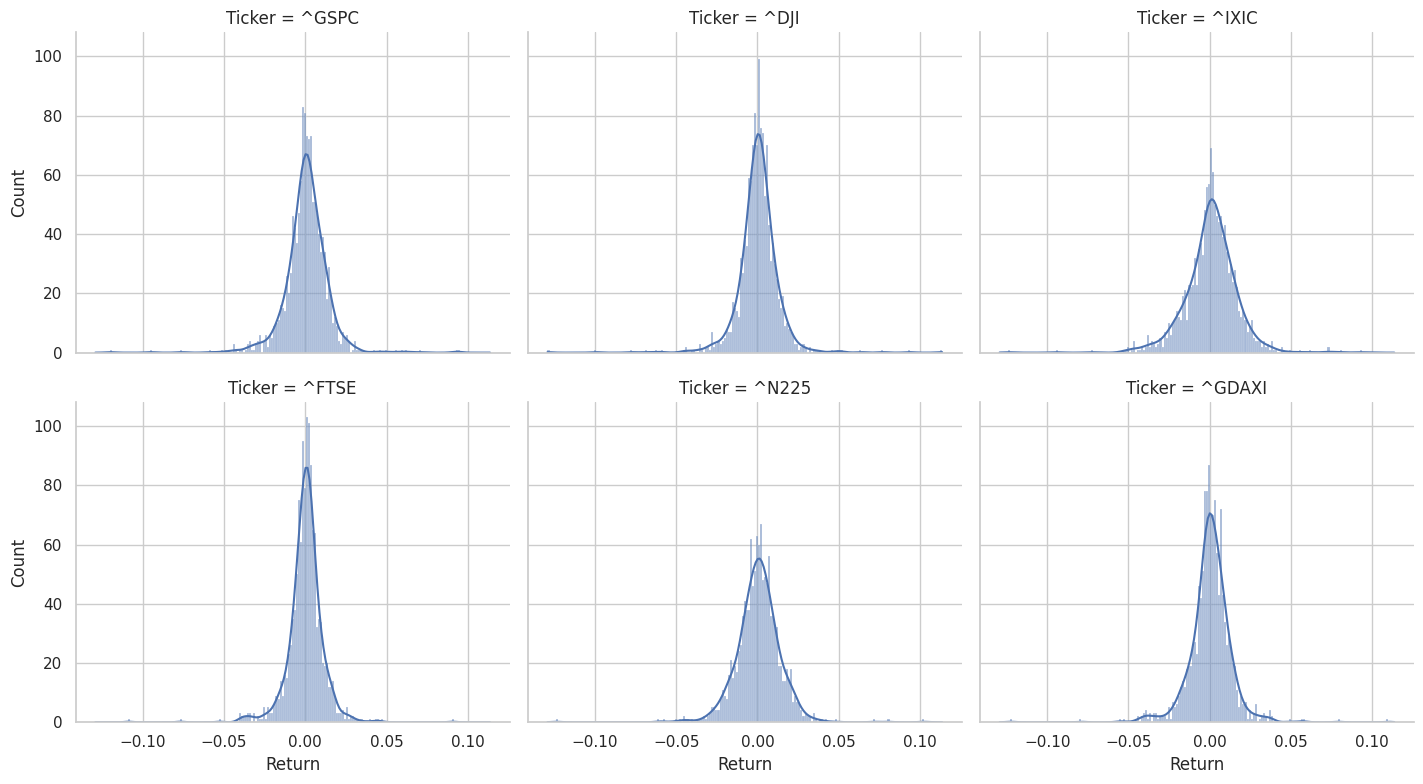

In [5]:
# TODO: daily returns
df["Return"] = df.groupby('Ticker')['Close'].pct_change()

# TODO: faceted distribution plot
g = sns.displot(
    data = df.dropna(subset = ['Return']),
    x = 'Return',
    col = 'Ticker',
    col_wrap = 3,
    kind = 'hist',
    kde = True,
    aspect = 1.2,
    height = 4
)

## Exercise 5 — Volatility comparison (15 pts)

The **standard deviation of daily returns** is a common (if simple) measure of an asset's risk / volatility.

1. Compute the standard deviation of daily returns per ticker.
2. Multiply by `√252` to annualize (252 trading days/year).
3. Display as a bar plot, sorted descending.
4. In the markdown cell, identify the most and least volatile index in this dataset.


/tmp/ipykernel_2537/1222691516.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


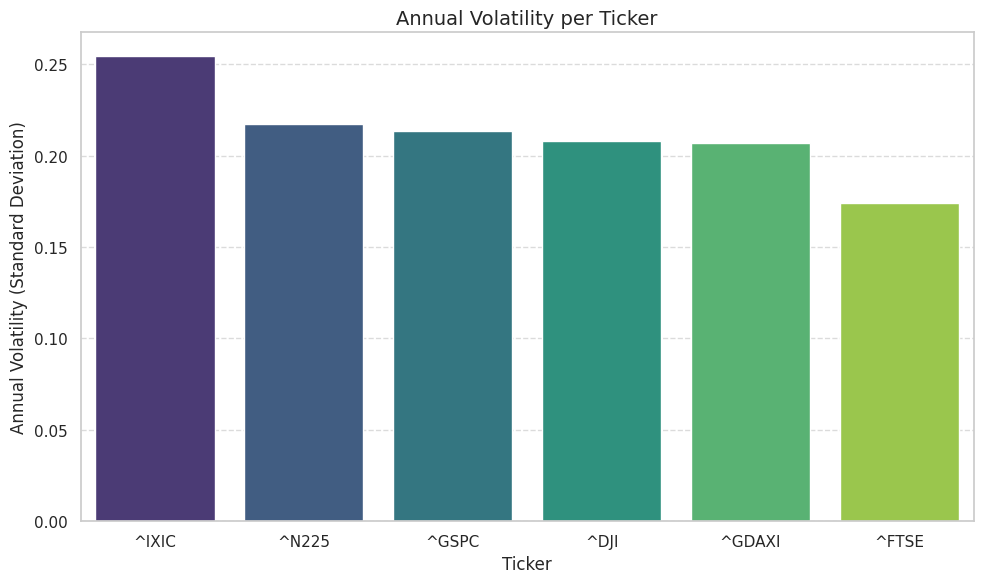

   Ticker  Annual Volatility
0   ^IXIC           0.254708
1   ^N225           0.217568
2   ^GSPC           0.213399
3    ^DJI           0.207817
4  ^GDAXI           0.207058
5   ^FTSE           0.173914


In [6]:
# TODO: annualized volatility per ticker, bar plot
daily_standard = df.groupby('Ticker')['Return'].std()
volatility = daily_standard * np.sqrt(252)

vol_sorted = volatility.sort_values(ascending=False).reset_index()
vol_sorted.columns = ['Ticker', 'Annual Volatility']
plt.figure(figsize=(10, 6))
sns.barplot(
    data = vol_sorted,
    x = 'Ticker',
    y = 'Annual Volatility',
    palette = 'viridis'
)

plt.title('Annual Volatility per Ticker', fontsize = 14)
plt.xlabel('Ticker', fontsize = 12)
plt.ylabel('Annual Volatility (Standard Deviation)', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

print(vol_sorted)

**YOUR ANSWER:** Most volatile = ____, least volatile = ____.



## Exercise 6 — Correlation between indices (15 pts)

Do the world's stock markets move together? Compute a correlation matrix of **daily returns** between tickers, and visualize it as a heatmap with `annot=True`.

Hint: you'll need to **pivot** the data first so each ticker is a column. Use `df.pivot(index="Date", columns="Ticker", values="Close").pct_change()`.


In [3]:
# TODO: pivot, compute returns, correlation, heatmap
daily_returns = df.pivot(index="Date", columns="Ticker", values="Close").pct_change()
correlation_matrix = daily_returns.corr()
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
    vmin = 1,
    vmax = 2,
    fmt = '.2f',
    linewidths = 0.5,
    square = True
)

plt.title('Correlation matrix of daily stock returns', fontsize = 14, pad = 20)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()

NameError: name 'df' is not defined

**YOUR ANSWER:** Which pair of indices is most correlated? Most weakly correlated? Does the geographic pattern make sense?



## Exercise 7 — Find the worst day (10 pts)

For each ticker, find the date of its **worst daily return** in the dataset. Display ticker, date, and return.

Then in the markdown cell, comment on whether the dates cluster around a common event.


In [6]:
# TODO: worst day per ticker
ticker_return = df.groupby('Ticker')['Date'].idxmin()

worst_return = df.loc[ticker_return, ['Ticker', 'Date']]

worsts_sorted = worst_return.sort_values(by = 'Date')

**YOUR ANSWER:** Are the worst days clustered? What might explain that?



## Exercise 8 — Reflection (10 pts)

In 4–6 sentences:
1. Compare the EDA workflow on this dataset (time-series, multiple entities) to the one on penguins (cross-sectional, single observation per row). What changed?
2. Name one **modeling question** this exploration would help you set up. (E.g., "Predict whether the S&P will close up tomorrow given recent returns of European indices.")

YOUR ANSWER:



## Submission checklist

- [ ] Name and date filled in
- [ ] All TODO cells completed and run
- [ ] All `YOUR ANSWER` prompts replaced
- [ ] **Restart & Run All** completes without errors
- [ ] Downloaded as `.ipynb` and uploaded to Canvas
